In [15]:
import numpy, pandas, sklearn, xgboost, shap, imblearn
print("numpy:", numpy.__version__)
print("All good!")

numpy: 2.0.2
All good!


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

print("Imports successful!")

Imports successful!


In [17]:
df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud %: {df['Class'].mean()*100:.4f}%")

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud %: 0.1727%


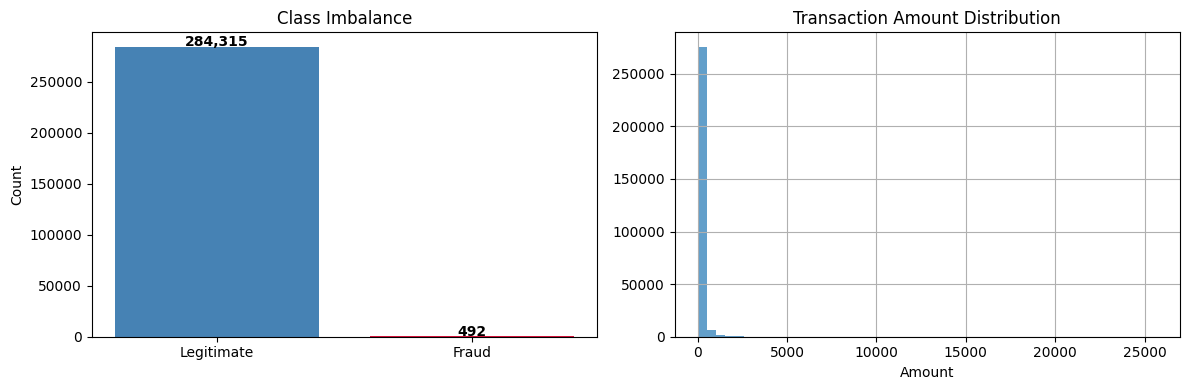

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Imbalance')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

df.groupby('Class')['Amount'].hist(bins=50, ax=axes[1], alpha=0.7)
axes[1].set_title('Transaction Amount Distribution')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

In [19]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

features = [c for c in df.columns if c not in ['Class', 'Amount', 'Time']]
X = df[features]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Before SMOTE — Fraud: {y_train.sum()}, Legit: {(y_train==0).sum()}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE  — Fraud: {y_train_res.sum()}, Legit: {(y_train_res==0).sum()}")

Before SMOTE — Fraud: 394, Legit: 227451
After SMOTE  — Fraud: 227451, Legit: 227451


In [20]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train_res, y_train_res)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.35      0.87      0.49        98

    accuracy                           1.00     56962
   macro avg       0.67      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9760


In [21]:
from sklearn.utils import resample

X_train_fast, y_train_fast = resample(
    X_train_res, y_train_res,
    n_samples=50000,
    random_state=42,
    stratify=y_train_res
)

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_fast, y_train_fast)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=['Legit', 'Fraud']))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.35      0.90      0.50        98

    accuracy                           1.00     56962
   macro avg       0.67      0.95      0.75     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC: 0.9788


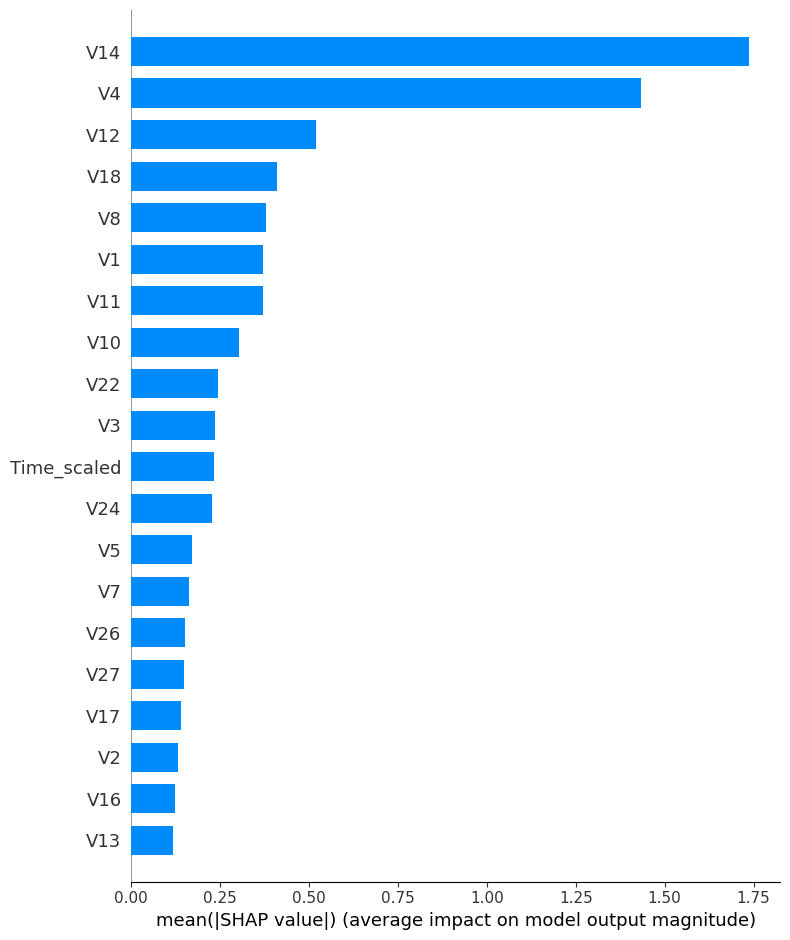

In [22]:
explainer = shap.TreeExplainer(xgb_model)
X_test_sample = X_test.iloc[:500]

shap_values = explainer.shap_values(X_test_sample)

plt.figure()
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=True)

Transaction #165
Actual label: LEGIT
Model probability: 0.9289


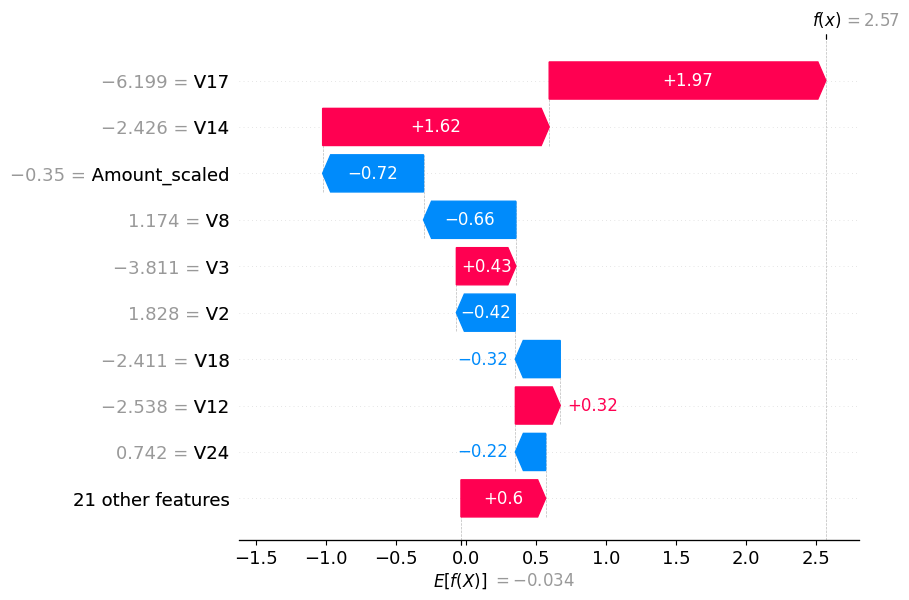

In [23]:
fraud_indices = np.where(xgb_preds == 1)[0]
idx = fraud_indices[0]

print(f"Transaction #{idx}")
print(f"Actual label: {'FRAUD' if y_test.iloc[idx]==1 else 'LEGIT'}")
print(f"Model probability: {xgb_proba[idx]:.4f}")

shap_explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[idx],
    feature_names=X_test_sample.columns.tolist()
)

shap.plots.waterfall(shap_explanation, show=True)

In [24]:
import joblib
import json

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

with open('feature_names.json', 'w') as f:
    json.dump(features, f)

print("Models saved!")

Models saved!


In [25]:
!pip install streamlit -q
!npm install -g localtunnel -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.3 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [26]:
%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import joblib
import json
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')

st.set_page_config(page_title="Fraud Detection Dashboard", page_icon="🔍", layout="wide")

@st.cache_resource
def load_models():
    xgb_model = joblib.load('xgb_model.pkl')
    rf_model  = joblib.load('rf_model.pkl')
    with open('feature_names.json') as f:
        features = json.load(f)
    explainer = shap.TreeExplainer(xgb_model)
    return xgb_model, rf_model, features, explainer

xgb_model, rf_model, features, explainer = load_models()

st.title("🔍 Credit Card Fraud Detection")
st.markdown("Enter transaction features below. The model will predict fraud probability and explain its reasoning.")
st.divider()

st.sidebar.header("Transaction Features")
col1, col2 = st.sidebar.columns(2)
use_fraud = col1.button("Load Fraud Sample")
use_legit = col2.button("Load Legit Sample")

fraud_sample = {f: 0.0 for f in features}
fraud_sample.update({'V14': -10.0, 'V4': 5.0, 'V12': -8.0, 'V17': -7.0, 'V11': 5.0, 'Amount_scaled': 2.5})

legit_sample = {f: 0.0 for f in features}
legit_sample.update({'V14': 0.5, 'V4': 0.3, 'Amount_scaled': -0.2})

if use_fraud:
    st.session_state['inputs'] = fraud_sample
elif use_legit:
    st.session_state['inputs'] = legit_sample
if 'inputs' not in st.session_state:
    st.session_state['inputs'] = {f: 0.0 for f in features}

key_features = ['V14','V4','V12','V17','V11','V10','V3','V1','V18','V8','Amount_scaled','Time_scaled']

input_values = {}
for feat in features:
    if feat in key_features:
        input_values[feat] = st.sidebar.slider(
            feat, min_value=-15.0, max_value=15.0,
            value=float(st.session_state['inputs'].get(feat, 0.0)), step=0.1
        )
    else:
        input_values[feat] = st.session_state['inputs'].get(feat, 0.0)

input_df = pd.DataFrame([input_values])

xgb_prob = xgb_model.predict_proba(input_df)[0][1]
rf_prob  = rf_model.predict_proba(input_df)[0][1]
ensemble_prob = (xgb_prob + rf_prob) / 2

st.subheader("Prediction Results")
m1, m2, m3, m4 = st.columns(4)
m1.metric("XGBoost Score", f"{xgb_prob:.1%}")
m2.metric("Random Forest", f"{rf_prob:.1%}")
m3.metric("Ensemble Score", f"{ensemble_prob:.1%}")

verdict = "🚨 FRAUD" if ensemble_prob > 0.5 else "✅ LEGITIMATE"
color = "red" if ensemble_prob > 0.5 else "green"
m4.markdown(f"### Verdict: <span style='color:{color}'>{verdict}</span>", unsafe_allow_html=True)

st.markdown("**Fraud Risk Level**")
st.progress(float(ensemble_prob))
st.divider()

st.subheader("Why did the model decide this?")
shap_values = explainer.shap_values(input_df)

tab1, tab2 = st.tabs(["Waterfall Plot", "Force Plot"])

with tab1:
    explanation = shap.Explanation(
        values=shap_values[0], base_values=explainer.expected_value,
        data=input_df.iloc[0], feature_names=features
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(explanation, show=False)
    st.pyplot(plt.gcf())
    plt.close()

with tab2:
    fig, ax = plt.subplots(figsize=(12, 3))
    shap.force_plot(explainer.expected_value, shap_values[0], input_df.iloc[0],
                     feature_names=features, matplotlib=True, show=False)
    st.pyplot(plt.gcf())
    plt.close()

st.divider()
st.subheader("Feature Contributions")
contrib_df = pd.DataFrame({
    'Feature': features, 'Value': input_df.iloc[0].values, 'SHAP Impact': shap_values[0]
})
contrib_df['Direction'] = contrib_df['SHAP Impact'].apply(lambda x: '🔴 Toward Fraud' if x > 0 else '🔵 Toward Legit')
contrib_df = contrib_df.reindex(contrib_df['SHAP Impact'].abs().sort_values(ascending=False).index)

st.dataframe(contrib_df.style.background_gradient(subset=['SHAP Impact'], cmap='RdBu_r'),
             use_container_width=True, hide_index=True)

Writing app.py


In [27]:
!wget -q -O - https://loca.lt/mytunnelpassword

34.26.238.29

In [28]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧your url is: https://busy-news-lie.loca.lt
^C


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
import os
project_path = '/content/drive/MyDrive/fraud-detection-shap'
os.makedirs(project_path, exist_ok=True)

import joblib
import json

joblib.dump(xgb_model, f'{project_path}/xgb_model.pkl')
joblib.dump(rf_model, f'{project_path}/rf_model.pkl')
joblib.dump(scaler, f'{project_path}/scaler.pkl')

with open(f'{project_path}/feature_names.json', 'w') as f:
    json.dump(features, f)

print("Saved to Google Drive!")

Saved to Google Drive!


In [33]:
print(os.listdir(project_path))

['xgb_model.pkl', 'rf_model.pkl', 'scaler.pkl', 'feature_names.json']
